## Scope: dataset creation and initial explorative analysis
The following notebook is used to explore, merge and perform data analysis on two datasets. 
The first dataset contains Credit Default Spreads (CDS) for 10 different maturities across 6 years (2015-2021). The second dataset contains corporate credit ratings given by major ratings' agencies. The aim is to smoothly merge the two datasets. 

The first section of the notebook focuses on exploratory data analysis performed on both sets to understand the data and ensure the subsequent merging of the two datasets. 
The second section implements the merging of the two datasets and gives final summary statistics regarding the newly created dataset.

Throughout the notebook, the analysis actively avoids looking at the data past the year 2015 to avoid look-ahead bias in the second part of the study. 




In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
load_dotenv()

path = os.getenv('macbook_path')
os.chdir(path)

## FIRST DATASET: Credit Default Spreads across 10 maturities

Source: https://www.kaggle.com/datasets/debashish311601/credit-default-swap-cds-prices/data

Brief description and limitations: 
- Maturities: 1y, 2y, 3y, 4y, 5y, 6y, 7y, 8y, 9y, 10y
- Data source: scraped from web, unknown single sources
- Unknown reference bonds
- Reconstructuring clause is not addressed 
- 661 entities



In [2]:
df = pd.read_csv('data/cds.csv', parse_dates=[0])
df.rename(columns={'Date': 'date', 'Ticker': 'ticker', 'Company': 'company'}, inplace=True)
df.head() # in bps

,date,ticker,company,PX1,PX2,PX3,PX4,PX5,PX6,PX7,PX8,PX9,PX10
0,2015-01-01,A,Agilent Technologies Inc,14.850,25.05,39.055,73.715,86.30,111.305,125.905,144.300,158.600,168.195
1,2015-01-02,A,Agilent Technologies Inc,14.855,25.15,39.160,73.600,86.40,111.510,126.100,144.375,158.775,168.375
2,2015-01-05,A,Agilent Technologies Inc,13.455,24.96,39.310,70.200,88.26,111.970,125.060,143.165,157.385,166.825
3,2015-01-06,A,Agilent Technologies Inc,15.535,24.88,39.300,72.680,91.10,116.610,130.890,150.365,165.655,175.885
4,2015-01-07,A,Agilent Technologies Inc,15.215,25.50,40.270,73.880,92.50,117.780,131.940,151.145,166.215,176.295


In [3]:
df.date.dt.year.unique() # years in the dataset

array([2015, 2016, 2017, 2018, 2019, 2020, 2021], dtype=int32)

In [4]:
# Adding columns for year and month
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

In [5]:
len(df['ticker'].unique())

661

## SECOND DATASET: Issuer ratings

Link: https://www.kaggle.com/datasets/agewerc/corporate-credit-rating

Brief description and limitations: 
- A list of 2029 credit ratings issued by major agencies to big US firms (traded on NYSE or Nasdaq), 
- Time period: 2005-2016 (most data is from 2010 on),
- There are 30 features for every company of which 25 are financial indicators,
- Sources: https://public.opendatasoft.com/explore/?sort=modified&orderBy=updated_at+DESC & financial indicators come from https://site.financialmodelingprep.com/market-indexes-major-markets


NOTICE: Ratings come from different agencies. Following the owner's idea, it's possible to separate into generic grades according to investment risk. To map out the the ratings we use the standard separation into Investment Grade and Speculative Grade, it is also employed in other studies (e.g. Cafarelli, 2018). 
We further divide into smaller categories, using the definitions given by each rating agency on their site: 
- Moody's: https://www.moodys.com/sites/products/productattachments/ap075378_1_1408_ki.pdf
- S&P: https://www.spglobal.com/ratings/en/credit-ratings/about/understanding-credit-ratings#scale
- Fitch: https://your.fitch.group/rating-definitions.html
- Egan Jones: https://www.egan-jones.com/understanding-ratings/egan-jones-rating-definitions/


In [6]:
# paper separates into 3 categories according to issuer credit ratings, uses only S&P ratings
# kaggle dataset has ratings from different agencies, but not for all initial entities
issuer_rating = pd.read_csv('data/corporate_rating.csv', parse_dates=['Date'],)# index_col=2)
issuer_rating.head()

,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2015-11-27,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2014-02-13,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,2015-03-06,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,2012-06-15,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,2016-10-24,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


In [7]:
issuer_rating.info()
issuer_rating.columns # merging on: 'Symbol', 'Year', 'Month', 'Rating'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2029 entries, 0 to 2028
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Rating                              2029 non-null   object        
 1   Name                                2029 non-null   object        
 2   Symbol                              2029 non-null   object        
 3   Rating Agency Name                  2029 non-null   object        
 4   Date                                2029 non-null   datetime64[ns]
 5   Sector                              2029 non-null   object        
 6   currentRatio                        2029 non-null   float64       
 7   quickRatio                          2029 non-null   float64       
 8   cashRatio                           2029 non-null   float64       
 9   daysOfSalesOutstanding              2029 non-null   float64       
 10  netProfitMargin         

Index(['Rating', 'Name', 'Symbol', 'Rating Agency Name', 'Date', 'Sector',
       'currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding',
       'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin',
       'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed',
       'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover',
       'debtEquityRatio', 'debtRatio', 'effectiveTaxRate',
       'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare',
       'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue',
       'enterpriseValueMultiple', 'operatingCashFlowPerShare',
       'operatingCashFlowSalesRatio', 'payablesTurnover'],
      dtype='object')

In [8]:
issuer_rating['Rating'].value_counts() # unbalanced
# Moody's has different ratings usually (Baa, Ba, Caa etc.) but here they use the same scale?)

Rating
BBB    671
BB     490
A      398
B      302
AA      89
CCC     64
AAA      7
CC       5
C        2
D        1
Name: count, dtype: int64

In [9]:
print(issuer_rating['Date'].describe())
print(sorted(issuer_rating['Date'].dt.year.unique())) # years from 2005 to 2016
print(f'Unique dates: {len(issuer_rating["Date"].unique())}') # 904 unique dates
print(f'Unique symbols: {len(issuer_rating["Symbol"].unique())}') # 593 unique symbols

count                             2029
mean     2014-07-31 06:53:03.045835264
min                2005-08-16 00:00:00
25%                2013-04-29 00:00:00
50%                2014-09-24 00:00:00
75%                2015-11-10 00:00:00
max                2016-12-23 00:00:00
Name: Date, dtype: object
[2005, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]
Unique dates: 904
Unique symbols: 593


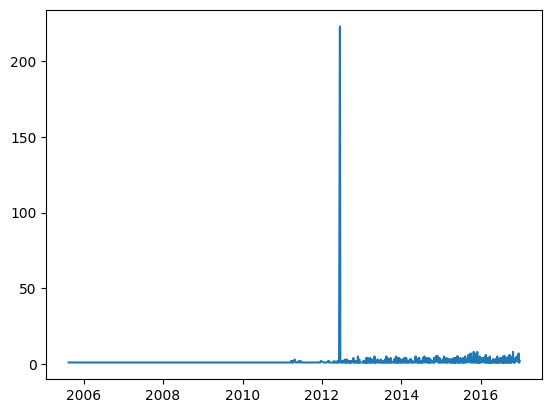

In [10]:
#issuer_rating.groupby(["Date"])['Symbol'].count()
plt.plot(issuer_rating.groupby(["Date"]).size()) 
plt.show()

In [11]:
# adding month and year columns
issuer_rating['Month'] = issuer_rating['Date'].dt.month
issuer_rating['Year'] = issuer_rating['Date'].dt.year
issuer_rating.head()

,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover,Month,Year
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2015-11-27,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655,11,2015
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2014-02-13,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846,2,2014
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,2015-03-06,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510,3,2015
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,2012-06-15,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150,6,2012
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,2016-10-24,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790,10,2016


In [12]:
# credit agencies
print(sorted(issuer_rating['Rating Agency Name'].unique()))

['DBRS', 'Egan-Jones Ratings Company', 'Fitch Ratings', "Moody's Investors Service", "Standard & Poor's Ratings Services"]


In [13]:
# tot ratings vs tickers
table_2 = issuer_rating.groupby('Symbol').size().value_counts().sort_index()
table_2.index.name = 'tot_ratings'
table_2
# max ratings per symbol = 7 (across multiple years) --> check each yr and month

tot_ratings
1    115
2     88
3    110
4    100
5     94
6     64
7     22
Name: count, dtype: int64

In [14]:
issuer_rating.groupby(['Year', 'Month']).size().unstack(fill_value=0)
# massive amnt of obs for 06/2012

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2005,0,0,0,0,0,0,0,1,0,0,0,0
2009,0,0,0,1,0,0,0,0,0,0,0,0
2010,0,0,0,0,0,0,0,2,1,0,2,4
2011,3,1,7,10,6,8,2,5,3,3,6,4
2012,1,4,4,6,9,231,16,20,17,14,25,10
2013,13,20,30,22,27,26,21,42,31,18,29,33
2014,28,23,29,20,44,33,30,38,36,24,52,26
2015,24,27,30,37,42,39,31,41,64,46,63,36
2016,25,41,40,23,24,28,28,48,53,50,34,34


In [15]:
# table with all tickers and tot obs for each year
ratings_per_ticker_year = (issuer_rating.groupby(['Symbol', 'Year']).size().unstack(fill_value=0)) 
ratings_per_ticker_year #593 tickers with ratings

ratings_per_ticker_year[ratings_per_ticker_year.ge(2).any(axis=1)] # keep only tickers with more than 1 rating in a year
print(len(ratings_per_ticker_year[ratings_per_ticker_year.ge(2).any(axis=1)].index)) # 326 tickers, which rating to keep? --> last available?

326


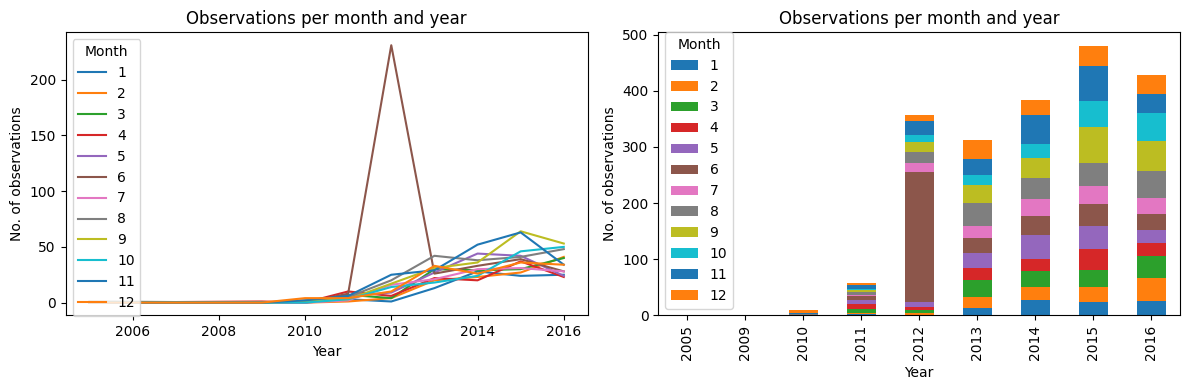

In [16]:
counts = issuer_rating.groupby(['Year', 'Month']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts.plot(kind='line', ax=axes[0])
axes[0].set_ylabel('No. of observations')
axes[0].set_title('Observations per month and year')

counts.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_ylabel('No. of observations')
axes[1].set_title('Observations per month and year')

plt.tight_layout()
plt.show()
# i can keep only one plot, remake with sns (!!)

In [17]:
# for df dataset relevant only 2015-2016
print('Tot. obs. for 2016:')
print(issuer_rating.groupby(['Year', 'Month']).size().unstack(fill_value=0).loc[2016].sum())
print('Tot. obs for 2015:')
print(issuer_rating.groupby(['Year', 'Month']).size().unstack(fill_value=0).loc[2015].sum())

Tot. obs. for 2016:
428
Tot. obs for 2015:
480


In [18]:
# drop all but 2015-2016
issuer_rating_15_16 = issuer_rating[(issuer_rating['Year'] >= 2015) & (issuer_rating['Year'] <= 2016)]
print(f'Obs. for 2015-2016: {len(issuer_rating_15_16)}')

Obs. for 2015-2016: 908


In [19]:
print(f'Tot. tickers: {len(issuer_rating["Symbol"].unique())}')
print(f'Tot. tickers in df: {len(df["ticker"].unique())}')

# INTERSECTION (ALL YEARS)
len(set(issuer_rating['Symbol'].unique()).intersection(set(df['ticker'].unique())))
common_tickers = list(set(issuer_rating['Symbol'].unique()).intersection(set(df['ticker'].unique())))
print(f'{sorted(common_tickers)[:20]} ...')
print(f'Common tickers: {len(common_tickers)}')

Tot. tickers: 593
Tot. tickers in df: 661
['AAPL', 'ABBV', 'ADM', 'AES', 'AMAT', 'AMGN', 'ANTM', 'APD', 'AVY', 'BA', 'BAX', 'BIDU', 'BLL', 'BMY', 'BSX', 'BWA', 'CAG', 'CAH', 'CAT', 'CCI'] ...
Common tickers: 138


In [20]:
# INTERSECTION (2015-2016 YEARS)
len(set(issuer_rating_15_16['Symbol'].unique()).intersection(set(df['ticker'].unique())))
common_tickers = list(set(issuer_rating_15_16['Symbol'].unique()).intersection(set(df['ticker'].unique())))
print(f'{sorted(common_tickers)[:20]} ...')
print(f'Common tickers: {len(common_tickers)}')

['AAPL', 'ABBV', 'ADM', 'AMAT', 'AMGN', 'APD', 'AVY', 'BAX', 'BIDU', 'BLL', 'BMY', 'BSX', 'BWA', 'CAG', 'CAH', 'CAT', 'CCI', 'CL', 'CMI', 'COP'] ...
Common tickers: 121


In [21]:
common_15_16 = issuer_rating_15_16.loc[issuer_rating_15_16['Symbol'].isin(common_tickers)]
common_15_16.to_csv('data/common_15_16.csv', index=False) #in case i need the table

## FINAL DATASET

The two datasets get merged by keeping the first (CDS) dataset as reference. 

In [22]:
# Final dataset preparation
# merging datasets to have ratings for all common tickers 
# since ratings are not available every single date --> merge on month/year, with repeated ratings for each month

# safety check : is there only 1 rating per month+year per ticker
table = issuer_rating.groupby(['Symbol', 'Year', 'Month']).size().unstack(fill_value=0)
table.loc[table.ge(2).any(axis=1)] #ok, no month has >=2 ratings per ticker


,Month,1,2,3,4,5,6,7,8,9,10,11,12
Symbol,Year,,,,,,,,,,,,


In [23]:
# merging datasets to have ratings for each ticker and month/year
# first merge only on ticker and month/year, 
# then filter df to have only tickers with ratings (drop the rest)
# df_m = df merged

df_m = pd.merge(df.reset_index(), issuer_rating_15_16, left_on=['ticker', 'year', 'month'], right_on=['Symbol', 'Year', 'Month'], how='left')

In [24]:
df_m.head()

,index,date,ticker,company,PX1,PX2,PX3,PX4,PX5,PX6,...,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover,Month,Year
0,0,2015-01-01,A,Agilent Technologies Inc,14.850,25.05,39.055,73.715,86.30,111.305,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2015-01-02,A,Agilent Technologies Inc,14.855,25.15,39.160,73.600,86.40,111.510,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2015-01-05,A,Agilent Technologies Inc,13.455,24.96,39.310,70.200,88.26,111.970,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2015-01-06,A,Agilent Technologies Inc,15.535,24.88,39.300,72.680,91.10,116.610,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2015-01-07,A,Agilent Technologies Inc,15.215,25.50,40.270,73.880,92.50,117.780,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
df_m.info() # cannot look at min max etc yet 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061167 entries, 0 to 1061166
Data columns (total 49 columns):
 #   Column                              Non-Null Count    Dtype         
---  ------                              --------------    -----         
 0   index                               1061167 non-null  int64         
 1   date                                1061167 non-null  datetime64[ns]
 2   ticker                              1061167 non-null  object        
 3   company                             1061167 non-null  object        
 4   PX1                                 1061167 non-null  float64       
 5   PX2                                 1061167 non-null  float64       
 6   PX3                                 1061167 non-null  float64       
 7   PX4                                 1061167 non-null  float64       
 8   PX5                                 1061167 non-null  float64       
 9   PX6                                 1061167 non-null  float64       

In [26]:
len(df_m['ticker'].unique()) # need to drop the tickers without ratings

661

In [27]:
# double cvhekc
apple = df_m[df_m['ticker'] == 'AAPL'].loc[:, ['date', 'year', 'month', 'ticker', 'PX1', 'Rating', 'Year', 'Month', 'currentRatio']]
apple.loc[apple['Year'] == 2015]

,date,year,month,ticker,PX1,Rating,Year,Month,currentRatio
3580,2015-05-01,2015,5,AAPL,6.800,AA,2015.0,5.0,1.080113
3581,2015-05-04,2015,5,AAPL,6.825,AA,2015.0,5.0,1.080113
3582,2015-05-05,2015,5,AAPL,6.670,AA,2015.0,5.0,1.080113
3583,2015-05-06,2015,5,AAPL,6.815,AA,2015.0,5.0,1.080113
3584,2015-05-07,2015,5,AAPL,6.810,AA,2015.0,5.0,1.080113
3585,2015-05-08,2015,5,AAPL,6.800,AA,2015.0,5.0,1.080113
3586,2015-05-11,2015,5,AAPL,6.675,AA,2015.0,5.0,1.080113
3587,2015-05-12,2015,5,AAPL,6.685,AA,2015.0,5.0,1.080113
3588,2015-05-13,2015,5,AAPL,6.830,AA,2015.0,5.0,1.080113
3589,2015-05-14,2015,5,AAPL,5.205,AA,2015.0,5.0,1.080113


In [28]:
# drop tickers with no ratings, aka keep only common tickers
df_m['ticker'].isin(common_tickers)
len(df_m.loc[df_m['ticker'].isin(common_tickers)]['ticker'].unique())

df_f = df_m.loc[df_m['ticker'].isin(common_tickers)]
df_f.head()

,index,date,ticker,company,PX1,PX2,PX3,PX4,PX5,PX6,...,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover,Month,Year
3494,3494,2015-01-01,AAPL,Apple Inc,8.300,11.100,12.900,16.800,23.600,31.800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3495,3495,2015-01-02,AAPL,Apple Inc,8.300,11.100,12.900,16.800,23.600,31.805,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3496,3496,2015-01-05,AAPL,Apple Inc,9.535,12.800,14.890,19.415,27.290,36.520,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3497,3497,2015-01-06,AAPL,Apple Inc,7.820,10.455,12.145,15.815,22.225,30.110,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3498,3498,2015-01-07,AAPL,Apple Inc,7.835,10.475,12.175,15.860,22.300,30.220,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
df_f['Rating'][df_f['Rating Agency Name']=='Moody\'s Investors Service'].unique() 
# Moody's scale analogous to S&P, 
# BBB = Baa already converted
# BB, B = Ba, B 
# C, CC, CCC = Caaa/Caa 
# D = C

array(['A', 'BBB', 'AA', 'BB', 'B'], dtype=object)

In [30]:
# RATING MAPPING
# Since rating agencies use different rating systems, map them to a common scale according to investment risk 
# Dataset is already converted to AAA-D scale, so mapping is straightforward
# We use the standard mapping (AAA-A: Low Risk, BBB: Medium Risk, BB-CCC: High Risk, CCC-D: Highest Risk)

print(df_f['Rating Agency Name'].unique()) # Morning Star DBRS disappeared after merging, so map only S&P, Moody's, Fitch, Egan-Jones

rating_map = {'AAA':'Low Risk', 
               'AA':'Low Risk',
               'A':'Low Risk',
               'BBB':'Medium Risk', 
               'BB':'High Risk',
               'B':'High Risk',
               'CCC':'High Risk', 
               'CC':'Highest Risk',
               'C':'Highest Risk',
               'D':'Highest Risk'}

df_f.insert(len(df_f.columns), 'CommonRating', np.nan) # add empty column
df_f['CommonRating'] = df_f['Rating'].map(rating_map)
df_f['CommonRating'].value_counts()
# CC-D no observations


[nan "Standard & Poor's Ratings Services" 'Egan-Jones Ratings Company'
 "Moody's Investors Service" 'Fitch Ratings']


/var/folders/ll/p_521hbd6dn_bzgvsslsglch0000gn/T/ipykernel_67238/4085357759.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_f['CommonRating'] = df_f['Rating'].map(rating_map)


CommonRating
Low Risk       2194
Medium Risk    1672
High Risk       391
Name: count, dtype: int64

In [31]:
# Creating a new column with the yearly rating by taking the LAST available rating in the year

df_f.insert(len(df_f.columns), 'YearlyRating', np.nan) # create empty column

for ticker in df_f['ticker'].unique():
    for year in df_f['year'].unique():
        mask = (df_f['ticker'] == ticker) & (df_f['year'] == year) # to select ticker and year
        yearly_data = df_f.loc[mask]
        if not yearly_data.empty: # proceed if there is data for that ticker and year
            all_y_ratings = yearly_data.sort_values(by='date')['CommonRating'].dropna()
            if not all_y_ratings.empty: # proceed if there are ratings available in that year
                last_rating = all_y_ratings.iloc[-1] # take the last available rating in the year
                df_f.loc[mask, 'YearlyRating'] = last_rating

df_f[['date', 'ticker', 'year', 'YearlyRating']].head(20) # should have a YearlyRating for all rows in 2015-2016
#df_f[['date', 'ticker', 'year', 'YearlyRating']].tail(10) from eyar 2016 no ratings

#mask = (df_f['ticker'] == 'AAPL') & (df_f['year'] == 2015)
#df_f.loc[mask]
#df_f.loc[mask].sort_values(by='date')['CommonRating'].dropna() # could become empty if there is no data for specific year
#df_f.loc[mask].sort_values(by='date')['CommonRating'].dropna().iloc[-1] # sort by date all the common ratings, remove the dates with no ratings and take the last one available


/var/folders/ll/p_521hbd6dn_bzgvsslsglch0000gn/T/ipykernel_67238/1154312918.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Low Risk' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_f.loc[mask, 'YearlyRating'] = last_rating


,date,ticker,year,YearlyRating
3494,2015-01-01,AAPL,2015,Low Risk
3495,2015-01-02,AAPL,2015,Low Risk
3496,2015-01-05,AAPL,2015,Low Risk
3497,2015-01-06,AAPL,2015,Low Risk
3498,2015-01-07,AAPL,2015,Low Risk
3499,2015-01-08,AAPL,2015,Low Risk
3500,2015-01-09,AAPL,2015,Low Risk
3501,2015-01-12,AAPL,2015,Low Risk
3502,2015-01-13,AAPL,2015,Low Risk
3503,2015-01-14,AAPL,2015,Low Risk


In [32]:
# CLEAN DATASET: df_f with only entities with ratings in 2015 !
#doublecheck
tickers2015 = df_f.loc[
    df_f['CommonRating'].notna() & (df_f['year'] == 2015), # filter for tickers with common rating and year 2015
    'ticker'].unique() # get unique tickers
len(tickers2015) # from 138 we drop to 96 entities
#checking that YearlyRating has been created correctly 
#sum(tickers2015 == df_f.loc[df_f['YearlyRating'].notna() & (df_f['year'] == 2015), 'ticker'].unique()) #order is the same bc of unique()
tickers2015 


array(['AAPL', 'ADM', 'AMAT', 'AMGN', 'APD', 'AVY', 'BAX', 'BLL', 'BMY',
       'BSX', 'BWA', 'CAG', 'CAH', 'CAT', 'CCI', 'CL', 'CMI', 'COP',
       'COST', 'CPB', 'CSX', 'CVS', 'D', 'DAL', 'DE', 'DHR', 'DOV', 'DTE',
       'EMN', 'EMR', 'ETN', 'ETR', 'FDX', 'FLEX', 'GD', 'GE', 'GIS',
       'GLW', 'GM', 'HAL', 'HES', 'HON', 'HPQ', 'HSY', 'IBM', 'IGT',
       'INTC', 'INTU', 'IP', 'ITW', 'JCI', 'K', 'KMB', 'LEN', 'LH', 'LLY',
       'LMT', 'MAS', 'MCK', 'MHK', 'MLM', 'MMC', 'MMM', 'MMP', 'MRO',
       'MSFT', 'NI', 'NOC', 'NSC', 'NUE', 'OC', 'OMC', 'ORCL', 'PAA',
       'PEP', 'PFE', 'PGR', 'PXD', 'SEE', 'SHW', 'SLB', 'SPGI', 'SRE',
       'SYY', 'TGT', 'TXN', 'UHS', 'UNH', 'UNP', 'VLO', 'VMC', 'VZ',
       'WEC', 'WHR', 'WMB', 'WY'], dtype=object)

In [33]:
tickers2016 = df_f.loc[
    df_f['CommonRating'].notna() & (df_f['year'] == 2016), # filter for tickers with common rating and year 2016           
    'ticker'].unique() # get unique tickers
tickers2016
len(tickers2016)
len(np.unique(np.concatenate([tickers2015, tickers2016])))

114

In [34]:
symbols_15_16 = issuer_rating.loc[(issuer_rating['Year'] == 2015) | (issuer_rating['Year'] == 2016), 'Symbol'].unique()
tickers_15_16 = df_m.loc[(df_m['year'] == 2015) | (df_m['year'] == 2016), 'ticker'].unique()
len(np.intersect1d(symbols_15_16, tickers_15_16))

114

In [35]:
len(df_f['ticker'].unique())

121

In [36]:
set(df_f['ticker'].unique()) - set(np.intersect1d(symbols_15_16, tickers_15_16)) # tickers in df_f with data past 2016

# e.g. AABV
# df_f.loc[df_f['ticker']=='ABBV'] # starts from 2017
# issuer_rating.loc[issuer_rating['Symbol']=='ABBV'] # ratings for 2014 and 2016 only

{'ABBV', 'BIDU', 'FIS', 'FISV', 'MPC', 'NFLX', 'WBA'}

In [37]:
# CLEAN DATASET: df_f with only entities with ratings in 2015 !
df_final = df_f.loc[df_f['ticker'].isin(tickers2015), ['date', 'month', 'year','ticker', 'company', 'PX1', 'PX2', 'PX3', 'PX4', 'PX5','PX6','PX7','PX8','PX9','PX10', 'YearlyRating']]
df_final.head()

,date,month,year,ticker,company,PX1,PX2,PX3,PX4,PX5,PX6,PX7,PX8,PX9,PX10,YearlyRating
3494,2015-01-01,1,2015,AAPL,Apple Inc,8.300,11.100,12.900,16.800,23.600,31.800,36.695,42.800,47.605,51.60,Low Risk
3495,2015-01-02,1,2015,AAPL,Apple Inc,8.300,11.100,12.900,16.800,23.600,31.805,36.705,42.800,47.605,51.60,Low Risk
3496,2015-01-05,1,2015,AAPL,Apple Inc,9.535,12.800,14.890,19.415,27.290,36.520,41.860,48.455,53.560,57.77,Low Risk
3497,2015-01-06,1,2015,AAPL,Apple Inc,7.820,10.455,12.145,15.815,22.225,30.110,34.905,40.905,45.670,49.67,Low Risk
3498,2015-01-07,1,2015,AAPL,Apple Inc,7.835,10.475,12.175,15.860,22.300,30.220,35.035,41.065,45.850,49.86,Low Risk


In [38]:
# Saving the dataset
df_final.to_csv('data/cleaned_cds_with_ratings.csv', index=False)

## Brief exploration of the new dataset

In [39]:
# Focus on 2015
focus = df_final.loc[df_final['year']==2015]

In [40]:
focus.describe()

,date,month,year,PX1,PX2,PX3,PX4,PX5,PX6,PX7,PX8,PX9,PX10
count,24738,24738.000000,24738.0,24738.000000,24738.000000,24738.000000,24738.000000,24738.000000,24738.000000,24738.000000,24738.000000,24738.000000,24738.000000
mean,2015-07-03 06:36:07.159834880,6.568801,2015.0,16.842173,26.795531,40.619457,56.715181,73.009933,87.162275,97.491507,104.497808,110.099595,114.550386
min,2015-01-01 00:00:00,1.000000,2015.0,1.955000,3.040000,4.900000,7.245000,11.560000,15.710000,17.000000,18.760000,19.565000,20.375000
25%,2015-04-02 00:00:00,4.000000,2015.0,5.935000,9.780000,15.960000,22.680000,30.732500,40.426250,47.136250,53.010000,58.006250,61.951250
50%,2015-07-03 00:00:00,7.000000,2015.0,9.345000,15.895000,26.035000,38.015000,50.365000,63.177500,72.465000,79.580000,84.770000,88.952500
75%,2015-10-02 00:00:00,10.000000,2015.0,15.585000,26.533750,42.823750,62.253750,82.708750,102.898750,116.035000,124.695000,131.322500,136.475000
max,2015-12-31 00:00:00,12.000000,2015.0,405.930000,435.030000,445.640000,451.140000,498.900000,534.485000,558.695000,574.430000,584.525000,591.640000
std,NaN,3.455475,0.0,27.302667,35.920536,46.389489,59.604162,71.331228,75.290130,78.728479,79.556771,80.388173,81.153894


As one would expect the mean increases as the time to maturity increases, the lowest CDS is quoted at 1.955 bps and the highest at 591.64 bps. 
Standard deviation also increases with time to maturity. Here we are looking at all entities, without distinctions of their percieved risk according to credit rating agencies. 

In [41]:
# LOW RISK TICKERS
focus.loc[focus.YearlyRating == 'Low Risk'].describe()

,date,month,year,PX1,PX2,PX3,PX4,PX5,PX6,PX7,PX8,PX9,PX10
count,14877,14877.000000,14877.0,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000
mean,2015-07-02 09:33:47.586206976,6.540230,2015.0,9.191039,14.680161,22.784744,32.035543,42.157108,53.127199,61.131929,67.452070,72.527576,76.530001
min,2015-01-01 00:00:00,1.000000,2015.0,1.955000,3.040000,4.900000,7.245000,11.560000,15.710000,17.000000,18.760000,19.565000,20.375000
25%,2015-04-02 00:00:00,4.000000,2015.0,5.270000,7.695000,12.550000,18.210000,25.095000,33.155000,39.460000,44.565000,49.215000,52.670000
50%,2015-07-02 00:00:00,7.000000,2015.0,7.315000,12.170000,19.885000,27.775000,36.870000,49.145000,58.445000,64.600000,69.360000,73.145000
75%,2015-10-01 00:00:00,10.000000,2015.0,11.205000,17.985000,27.975000,39.955000,51.905000,64.840000,74.760000,81.475000,87.380000,92.225000
max,2015-12-31 00:00:00,12.000000,2015.0,81.605000,134.105000,150.730000,180.175000,200.590000,210.280000,214.165000,221.355000,235.270000,246.160000
std,NaN,3.452489,0.0,6.575752,10.514055,13.862145,18.199373,22.551720,25.520932,27.831401,28.969437,30.009392,30.844570


In [42]:
# MEDIUM RISK TICKERS
focus.loc[focus.YearlyRating == 'Medium Risk'].describe()

,date,month,year,PX1,PX2,PX3,PX4,PX5,PX6,PX7,PX8,PX9,PX10
count,7437,7437.000000,7437.0,7437.000000,7437.000000,7437.000000,7437.000000,7437.000000,7437.000000,7437.000000,7437.000000,7437.000000,7437.000000
mean,2015-07-04 00:01:56.175877376,6.592578,2015.0,23.813605,36.375926,54.598120,76.264191,96.217133,113.146425,125.526142,133.177469,139.170305,143.972892
min,2015-01-01 00:00:00,1.000000,2015.0,2.805000,3.370000,5.955000,9.655000,13.615000,19.820000,23.740000,28.985000,32.910000,35.945000
25%,2015-04-03 00:00:00,4.000000,2015.0,8.350000,14.950000,26.050000,39.875000,52.810000,65.580000,75.325000,81.650000,86.755000,90.905000
50%,2015-07-06 00:00:00,7.000000,2015.0,12.755000,21.510000,37.105000,56.210000,77.235000,95.235000,108.755000,117.465000,124.420000,129.675000
75%,2015-10-02 00:00:00,10.000000,2015.0,24.125000,44.300000,68.955000,99.345000,114.770000,140.840000,159.895000,171.685000,178.920000,184.610000
max,2015-12-31 00:00:00,12.000000,2015.0,211.885000,222.275000,258.600000,375.165000,441.160000,475.835000,495.205000,502.900000,504.855000,504.605000
std,NaN,3.452426,0.0,29.471641,37.592729,47.689628,59.351763,66.854734,68.510689,70.435251,70.842383,71.284430,71.695076


In [43]:
# HIGH RISK TICKERS
focus.loc[focus.YearlyRating == 'High Risk'].describe()

,date,month,year,PX1,PX2,PX3,PX4,PX5,PX6,PX7,PX8,PX9,PX10
count,2424,2424.000000,2424.0,2424.000000,2424.000000,2424.000000,2424.000000,2424.000000,2424.000000,2424.000000,2424.000000,2424.000000,2424.000000
mean,2015-07-06 10:14:51.089108736,6.671205,2015.0,42.411225,71.758793,107.190293,148.205681,191.164033,216.327164,234.631714,243.870248,251.502255,257.625505
min,2015-01-01 00:00:00,1.000000,2015.0,6.025000,12.410000,20.555000,30.430000,43.355000,57.680000,67.440000,74.350000,80.060000,84.755000
25%,2015-04-06 00:00:00,4.000000,2015.0,15.957500,29.952500,49.900000,82.102500,113.777500,133.147500,147.687500,159.930000,169.448750,177.985000
50%,2015-07-08 00:00:00,7.000000,2015.0,24.950000,49.552500,80.985000,114.612500,155.330000,183.087500,203.652500,215.415000,223.530000,229.805000
75%,2015-10-08 00:00:00,10.000000,2015.0,39.700000,76.383750,122.135000,165.821250,216.036250,251.392500,279.421250,290.470000,297.736250,303.726250
max,2015-12-31 00:00:00,12.000000,2015.0,405.930000,435.030000,445.640000,451.140000,498.900000,534.485000,558.695000,574.430000,584.525000,591.640000
std,NaN,3.481983,0.0,59.301048,70.367779,82.610524,100.692930,116.804043,116.591456,118.123654,116.958438,116.562465,116.662746


Naive first impression: it seems like rating agencies are on average doing a "good" job, the low risk group has on average smaller spreads than the medium risk and much smaller than the high risk group. Volatility is much higher in the high risk group than in any other, as soon as from the 1y to maturity CDS. 

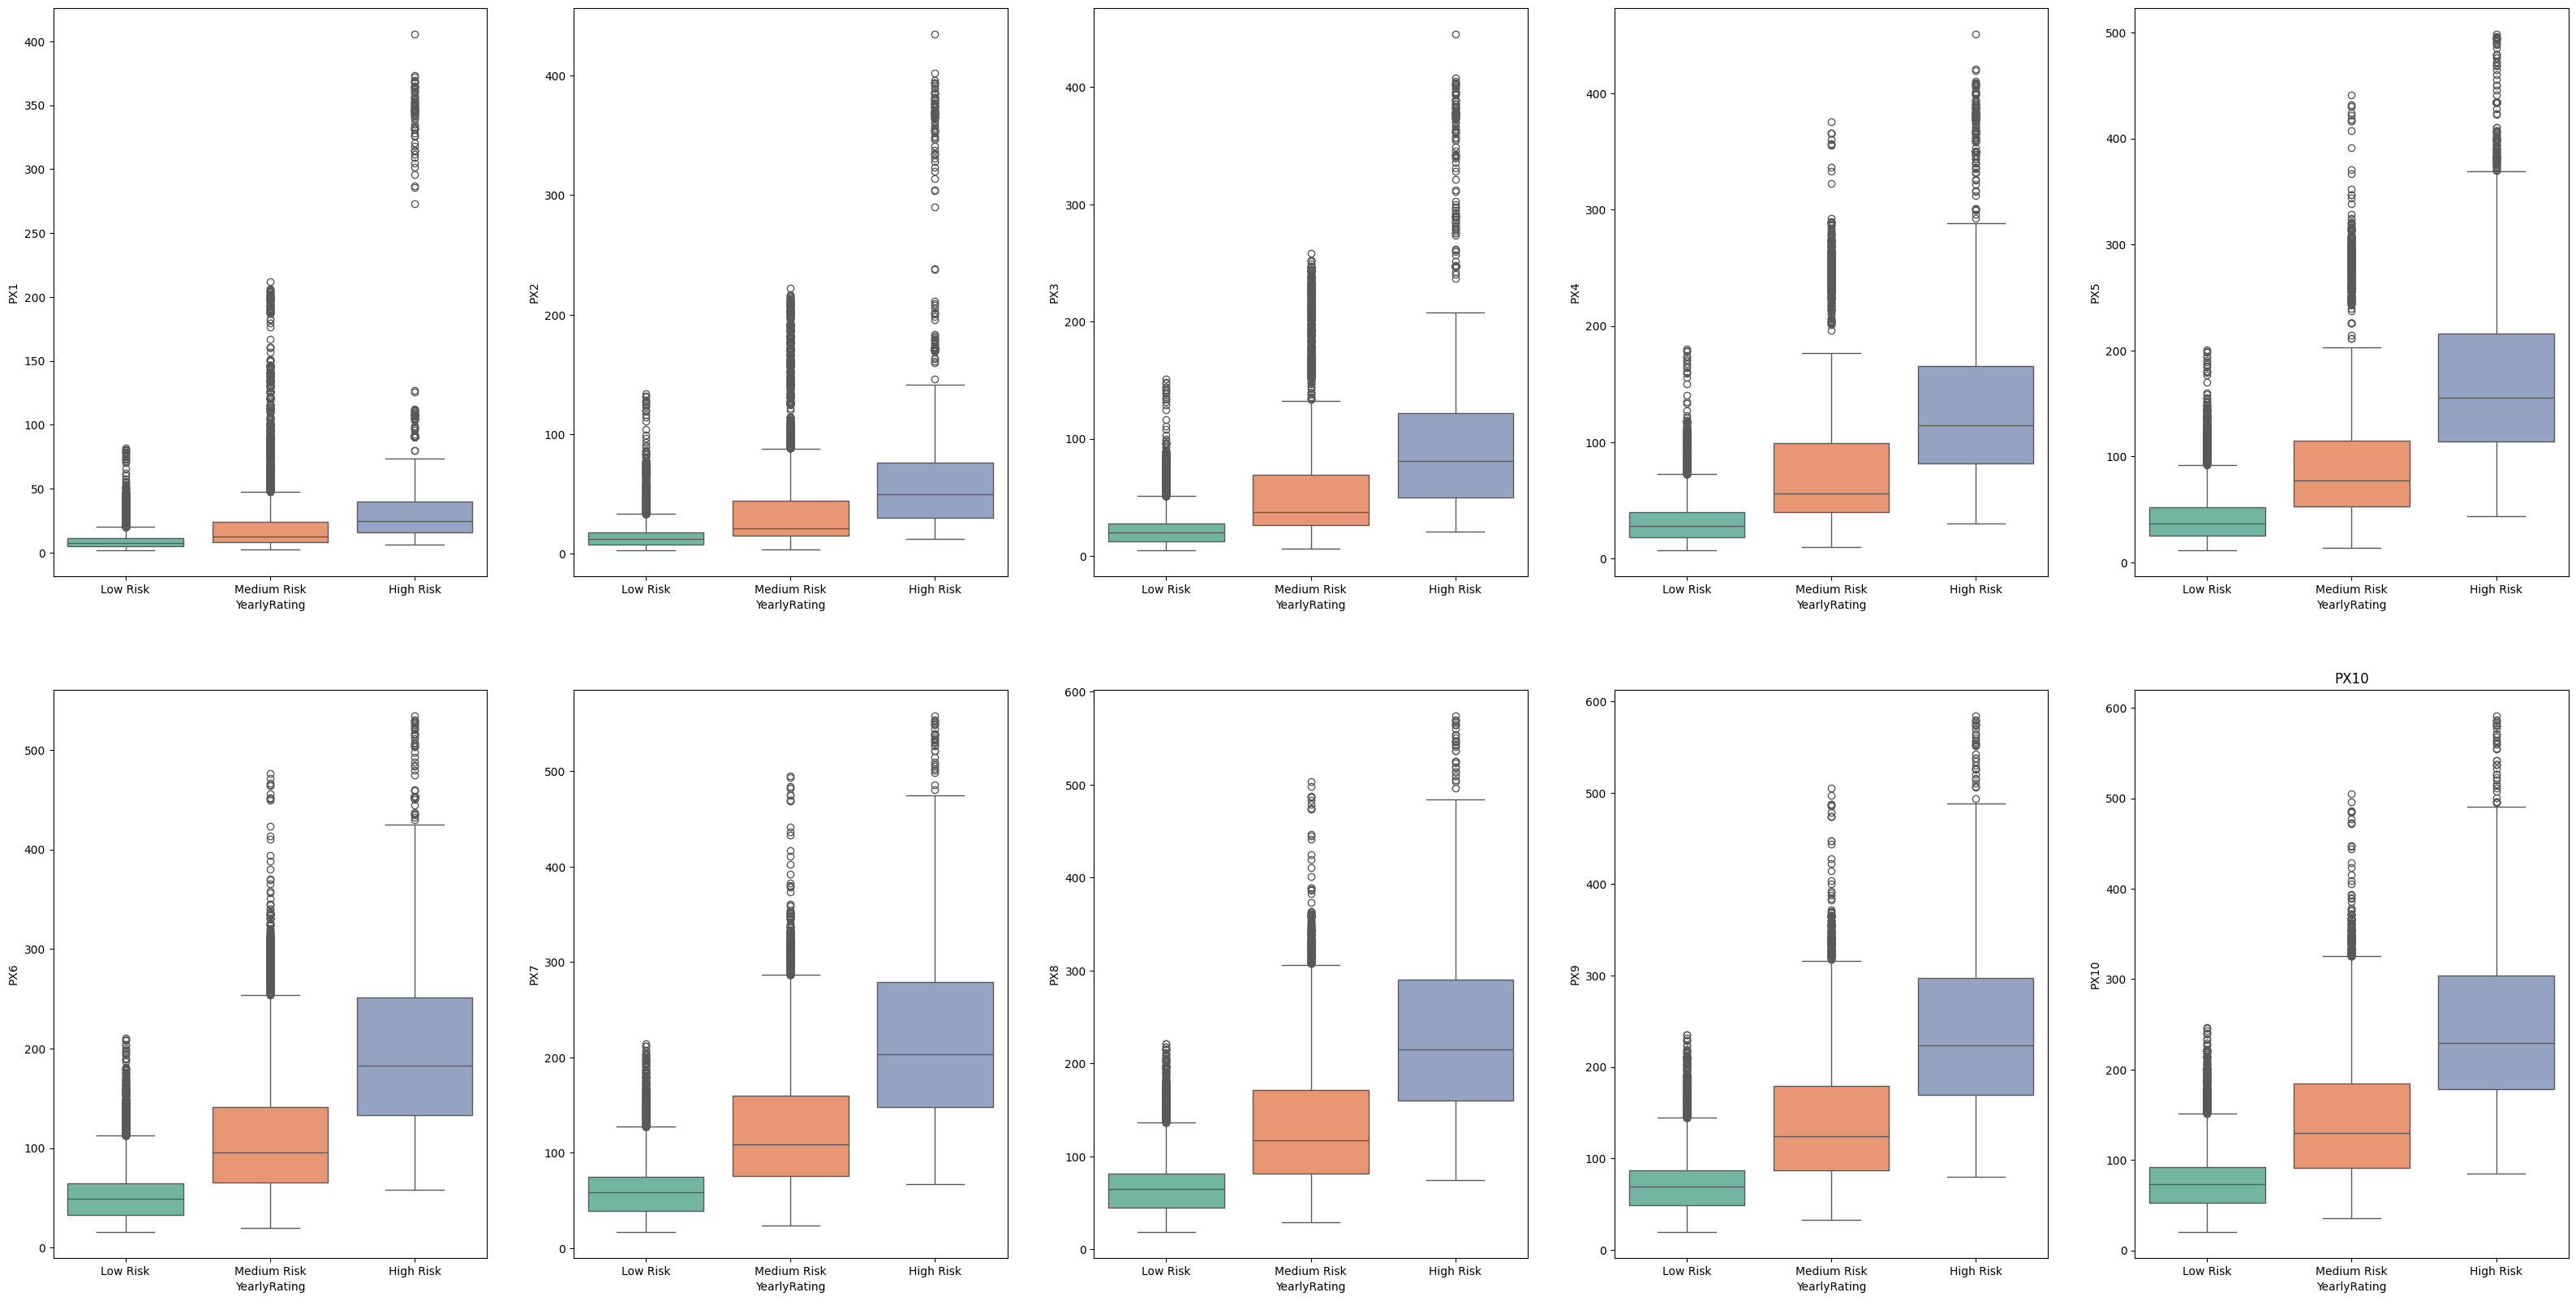

In [44]:
# Boxplots for 2015 (all tickers, all dates)
figure, axes = plt.subplots(nrows=2, ncols=5, figsize=(40,20))

i = 0 
j = 0

for c in focus.columns[5:15]:
    
    sns.boxplot(x=focus['YearlyRating'], y=focus[c], hue=focus['YearlyRating'], palette='Set2', ax=axes[i, j])
    plt.title(focus[c].name)
    if j == 4:
        j=0
        i+=1
    else:
        j+=1  
plt.show()

In [45]:
# Plotting term structures -> ONE ENTITY
def plot_term_structure(df, ticker, date):
    df_sel = df[(df["ticker"] == ticker) & (df["date"] == date)]

    px_cols = [f"PX{i}" for i in range(1, 11)] # columns PX1, PX2 etc.

    df_long = df_sel.melt(
        value_vars=px_cols,
        var_name='Time to Maturity',
        value_name='CDS spread (bps)'
    )

    df_long['Time to Maturity'] = df_long['Time to Maturity'].str.replace("PX", "").astype(int) # leave only numbers from 1 to 10

    graph = sns.lineplot(data=df_long, x='Time to Maturity', y='CDS spread (bps)', hue=0, palette='Set2', marker="o")
    graph.get_legend().remove()
    plt.title(f"Term Structure for {ticker} on {date}")
    plt.xticks(range(1, 11))

    plt.show()



In [46]:
# Plotting term structures -> LIST OF ENTITIES
def plot_terms(df, tickers, date, ax): # had to add ax to plot nicely
    df_sel = df[
        (df["ticker"].isin(tickers)) &
        (df["date"] == date)
    ]

    px_cols = [f"PX{i}" for i in range(1, 11)]

    df_long = df_sel.melt(
        id_vars=["ticker"], # keep track of tickers it refers to
        value_vars=px_cols,
        var_name="Time to Maturity",
        value_name="CDS spread (bps)"
    )

    df_long["Time to Maturity"] = (
        df_long["Time to Maturity"]
        .str.replace("PX", "", regex=False)
        .astype(int)
    )

    # plot one curve per ticker
    for ticker, sub in df_long.groupby("ticker"):
        ax.plot(
            sub["Time to Maturity"],
            sub["CDS spread (bps)"],
            marker="o",
            label=ticker
        )

    ax.set_xlabel("Time to Maturity (Years)")
    ax.set_ylabel("CDS spread (bps)")
    ax.legend()

In [47]:
low_risk_tickers = focus.loc[focus['YearlyRating']=='Low Risk', 'ticker'].unique()
med_risk_tickers = focus.loc[focus['YearlyRating']=='Medium Risk', 'ticker'].unique()
high_risk_tickers = focus.loc[focus['YearlyRating']=='High Risk', 'ticker'].unique()

print(f'Low risk entities ({len(low_risk_tickers)}): {low_risk_tickers}')
print(f'Medium risk entities ({len(med_risk_tickers)}): {med_risk_tickers}')
print(f'High risk entities ({len(high_risk_tickers)}): {high_risk_tickers}')

Low risk entities (57): ['AAPL' 'ADM' 'AMAT' 'APD' 'BMY' 'BWA' 'CAH' 'CL' 'CMI' 'COST' 'CPB' 'CSX'
 'CVS' 'D' 'DE' 'DHR' 'DOV' 'DTE' 'EMR' 'ETN' 'ETR' 'FDX' 'GD' 'GE' 'HAL'
 'HON' 'HSY' 'IBM' 'INTC' 'INTU' 'ITW' 'JCI' 'KMB' 'LLY' 'MMC' 'MMM' 'MMP'
 'MSFT' 'NOC' 'NSC' 'OMC' 'ORCL' 'PEP' 'PFE' 'PGR' 'SHW' 'SLB' 'SPGI'
 'SRE' 'TGT' 'TXN' 'UNH' 'UNP' 'VLO' 'VZ' 'WEC' 'WHR']
Medium risk entities (29): ['AMGN' 'AVY' 'BAX' 'CAG' 'CAT' 'CCI' 'COP' 'DAL' 'EMN' 'GIS' 'GLW' 'GM'
 'HPQ' 'IP' 'K' 'LH' 'LMT' 'MCK' 'MHK' 'MLM' 'NI' 'NUE' 'OC' 'PAA' 'PXD'
 'SYY' 'UHS' 'VMC' 'WY']
High risk entities (10): ['BLL' 'BSX' 'FLEX' 'HES' 'IGT' 'LEN' 'MAS' 'MRO' 'SEE' 'WMB']


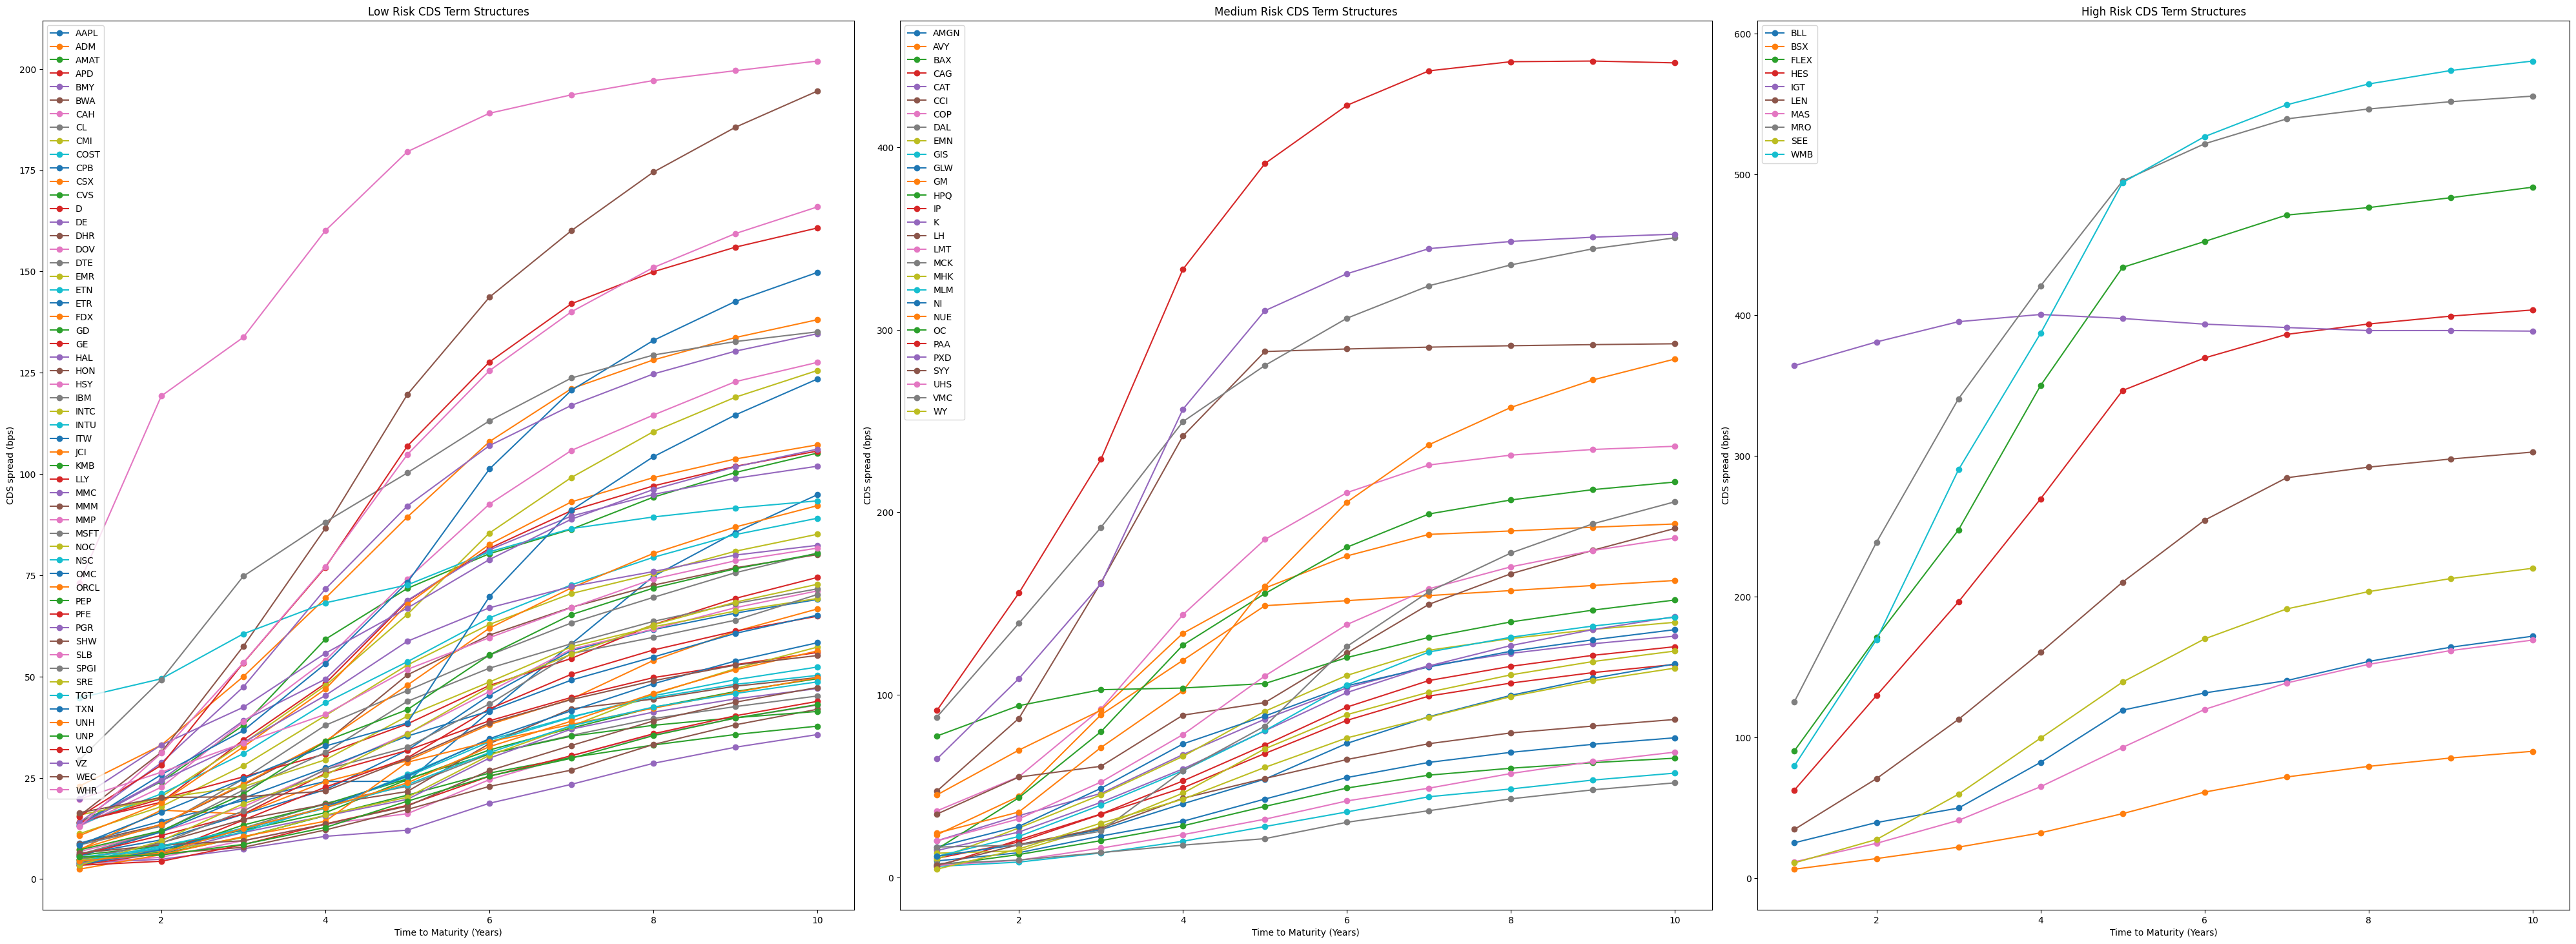

In [48]:
# Term structures
date = np.datetime64("2015-12-31")

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(40, 15))

risk_groups = [
    (low_risk_tickers,  "Low Risk"),
    (med_risk_tickers,  "Medium Risk"),
    (high_risk_tickers, "High Risk"),
]

for ax, (tickers, title) in zip(axes, risk_groups):
    plot_terms(focus, tickers, date, ax)
    ax.set_title(f"{title} CDS Term Structures")

plt.tight_layout()
plt.show()


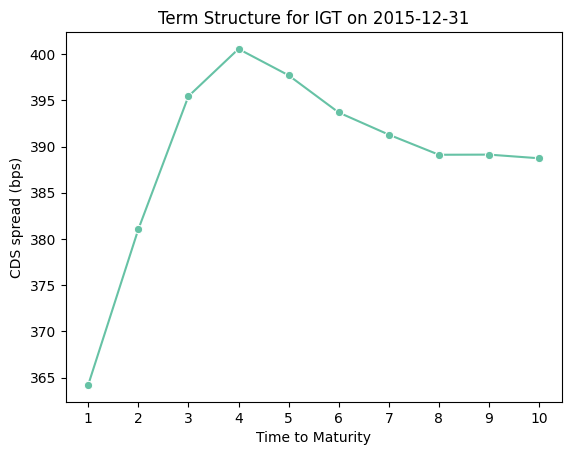

             date  month  year ticker                            company  \
485301 2015-12-31     12  2015    IGT  International Game Technology Plc   

           PX1     PX2     PX3      PX4    PX5     PX6      PX7     PX8  \
485301  364.22  381.04  395.43  400.555  397.7  393.68  391.285  389.11   

            PX9    PX10 YearlyRating  
485301  389.125  388.73    High Risk  


In [49]:
plot_term_structure(focus,'IGT',date)
print(focus.loc[(focus['ticker']=='IGT') & (focus['date']==date)])
####### perhaps add plots for first 3 singular term structures of each category 

Most term structures behave as we would expect them, CDS spreads are much lower when the maturity is near and they increase as the maturity increases. Some of the term structures are much humper than others, implying the spreads increase at higher rates in the beginning and they get somewhat flat when the maturities are far enough in the future (generally past 6 years). 

There are however a few apparent exceptions. For instance, in the High Risk group of entities, the values for the ticker 'IGT' (International Game Technology Plc) seem to oscillate less than for all the others so the curve is much flatter. This is due to an unusual initial high spread: the CDS with 1 year to maturity is already at 364.22 bps.

In [50]:
# Highest spread in low risk group 
focus[focus['PX10'] == focus.loc[focus.YearlyRating == 'Low Risk'].PX10.max()] 
# focus[focus['PX10'] == 246.160000]


,date,month,year,ticker,company,PX1,PX2,PX3,PX4,PX5,PX6,PX7,PX8,PX9,PX10,YearlyRating
176918,2015-09-29,9,2015,BWA,BorgWarner Inc,28.32,44.905,75.27,110.345,148.785,180.735,203.21,221.355,235.27,246.16,Low Risk


In [51]:
# Lowest spreads in low risk group 
focus[focus['PX10'] == focus.loc[focus.YearlyRating == 'Low Risk'].PX10.min()] 

,date,month,year,ticker,company,PX1,PX2,PX3,PX4,PX5,PX6,PX7,PX8,PX9,PX10,YearlyRating
621359,2015-01-14,1,2015,MMM,3M Co,2.92,3.665,6.29,7.68,14.725,15.995,17.0,18.76,19.565,20.375,Low Risk


In [52]:
# do we see concentrations in sectors ? 
issuer_rating.loc[issuer_rating['Symbol'].isin(focus['ticker'].unique())].head()

,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover,Month,Year
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2015-11-27,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655,11,2015
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2014-02-13,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846,2,2014
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,2015-03-06,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510,3,2015
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,2012-06-15,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150,6,2012
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,2016-10-24,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790,10,2016


In [53]:
# Adding "Sector" column to the df
ticker_sector = (issuer_rating.loc[issuer_rating['Symbol'].isin(focus['ticker'].unique())] # bc i don't need to map all tickers
        .drop_duplicates(subset='Symbol').set_index('Symbol')['Sector'] #keep each ticker only once and get according sector
)
#ticker_sector
ticker_sector = ticker_sector.reset_index()
mapped_sectors = focus.merge(ticker_sector, how='left', left_on=['ticker'], right_on=['Symbol']) # adds mapping to df

In [54]:
# Table with abs frequencies 
for risk in ['Low Risk','Medium Risk', 'High Risk']:
    sector_counts = (mapped_sectors.loc[mapped_sectors['YearlyRating'] == risk, ['ticker', 'Sector']] #filter
            .drop_duplicates(subset='ticker') #since there are repetitions (coming from having multiple dates)
            .groupby('Sector')
            .size() #get totals for each sector
    )
    #sector_counts

    if risk == 'Low Risk': 
        heatmap_data = sector_counts.to_frame(name='Low Risk') # creates the dataframe
    else:
        heatmap_data.insert(len(heatmap_data.columns),risk,sector_counts) #add columns

heatmap_data

,Low Risk,Medium Risk,High Risk
Sector,,,
Basic Industries,1,6.0,2.0
Capital Goods,6,4.0,1.0
Consumer Durables,2,2.0,1.0
Consumer Non-Durables,5,4.0,NaN
Consumer Services,4,2.0,1.0
Energy,7,3.0,2.0
Finance,3,NaN,NaN
Health Care,7,5.0,1.0
Public Utilities,6,1.0,1.0


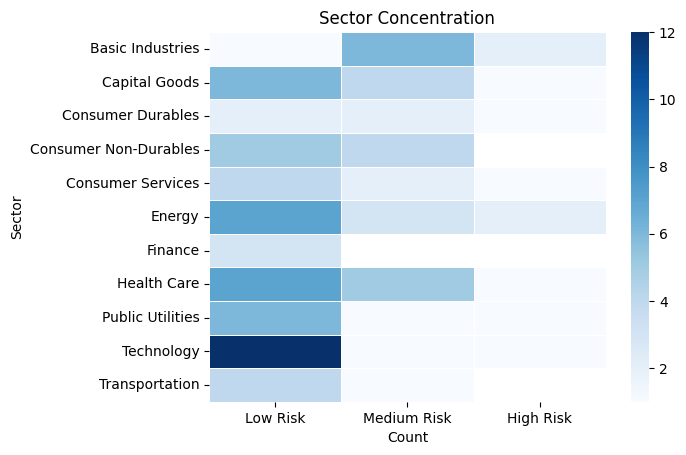

In [55]:
sns.heatmap(heatmap_data,cmap='Blues',linewidths=0.5)
plt.title('Sector Concentration')
plt.xlabel('Count')
plt.show()


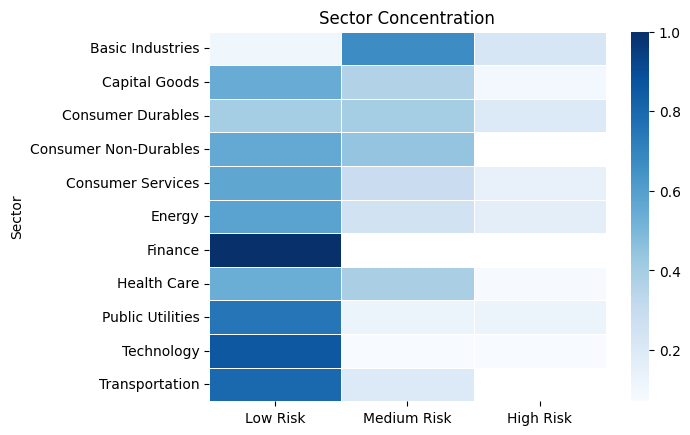

In [56]:
# normalzied over tot 
all_sector_counts = (
    mapped_sectors[['ticker', 'Sector']]
        .drop_duplicates(subset='ticker')
        .groupby('Sector')
        .size()
)
all_sector_counts = all_sector_counts.to_frame(name='All')

heatmap_norm = heatmap_data[['Low Risk','Medium Risk', 'High Risk']] / all_sector_counts.values
sns.heatmap(
    heatmap_norm,
    #annot=True,
    cmap='Blues',
    linewidths=0.5
)

plt.title('Sector Concentration')
plt.ylabel('Sector')
plt.show()


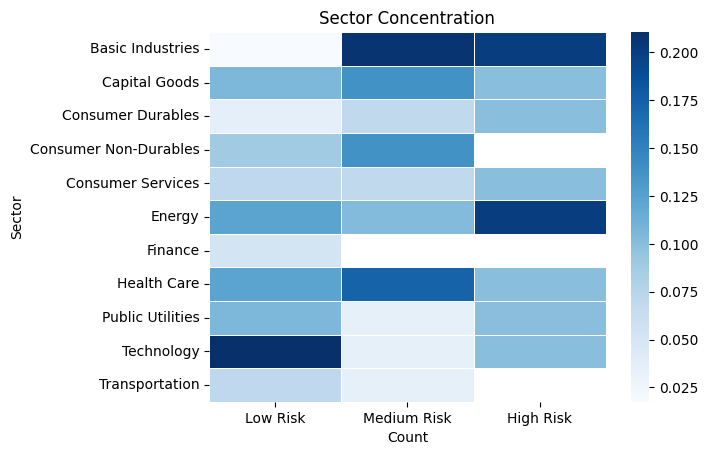

In [57]:
# normalizing each category 

for risk in ['Low Risk','Medium Risk', 'High Risk']:
    sector_counts = (mapped_sectors.loc[mapped_sectors['YearlyRating'] == risk, ['ticker', 'Sector']] #filter
            .drop_duplicates(subset='ticker') #since there are repetitions (coming from having multiple dates)
            .groupby('Sector')
            .size() #get totals for each sector
    )
    sector_counts = sector_counts / sector_counts.sum()

    if risk == 'Low Risk': 
        heatmap_data = sector_counts.to_frame(name='Low Risk') # creates the dataframe
    else:
        heatmap_data.insert(len(heatmap_data.columns),risk,sector_counts) #add columns


sns.heatmap(heatmap_data,cmap='Blues',linewidths=0.5)
plt.title('Sector Concentration')
plt.xlabel('Count')
plt.show()

The next notebook focuses on calibrating the CE model parameters to these known term structures and see how well (in terms of goodness of fit) and fast the model performs. 